# Traffic Flow Model Evaluation and Visualisation

This notebook compares the trained **LSTM**, **GRU**, and **CNN** traffic-flow prediction models.

The notebook **does not train models and does not run prediction again**. It reads the three shared output files already created when the training scripts were executed:

```text
saved_models/model_metrics.csv
saved_models/model_training_history.csv
saved_models/model_test_predictions.csv
```

Run these scripts before using this notebook:

```bash
python3 models/train_lstm.py
python3 models/train_gru.py
python3 models/train_cnn.py
```


## 1. Load saved evaluation outputs


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd()
if (CWD / "saved_models").exists():
    project_root = CWD
elif (CWD.parent / "saved_models").exists():
    project_root = CWD.parent
else:
    raise FileNotFoundError(
        "Cannot find saved_models folder. Open this notebook from the project root or models folder."
    )

saved_dir = project_root / "saved_models"
metrics_file = saved_dir / "model_metrics.csv"
history_file = saved_dir / "model_training_history.csv"
predictions_file = saved_dir / "model_test_predictions.csv"

required_files = [metrics_file, history_file, predictions_file]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing evaluation output files. Run all training scripts first:\n"
        + "\n".join(missing_files)
    )

metrics_df = pd.read_csv(metrics_file)
history_df = pd.read_csv(history_file)
predictions_df = pd.read_csv(predictions_file)
predictions_df["target_timestamp"] = pd.to_datetime(predictions_df["target_timestamp"])

print("Loaded metrics:", metrics_file)
print("Loaded training history:", history_file)
print("Loaded test predictions:", predictions_file)

display(metrics_df)


Loaded metrics: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/saved_models/model_metrics.csv
Loaded training history: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/saved_models/model_training_history.csv
Loaded test predictions: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/saved_models/model_test_predictions.csv


,Model,MAE,RMSE,R2,WAPE_percent,MAPE_percent
0,LSTM,37.241553,48.927704,0.967662,10.351649,48.575329
1,GRU,33.451945,45.645746,0.971854,9.298291,38.313892
2,CNN,32.442052,45.917265,0.971519,9.017582,28.824109


## 2. Check all model results and rank models


In [2]:
expected_models = {"LSTM", "GRU", "CNN"}

for output_name, output_df in [
    ("metrics", metrics_df),
    ("training history", history_df),
    ("test predictions", predictions_df),
]:
    missing_models = expected_models - set(output_df["Model"])
    if missing_models:
        print(f"Missing {output_name} for:", sorted(missing_models))
    else:
        print(f"All three models are available in {output_name}.")

comparison_df = metrics_df.sort_values("RMSE", ascending=True).reset_index(drop=True)
display(comparison_df)

best_model = comparison_df.loc[0, "Model"]
best_rmse = comparison_df.loc[0, "RMSE"]

print(f"Best model based on lowest RMSE: {best_model}")
print(f"Lowest RMSE: {best_rmse:.4f}")


All three models are available in metrics.
All three models are available in training history.
All three models are available in test predictions.


,Model,MAE,RMSE,R2,WAPE_percent,MAPE_percent
0,GRU,33.451945,45.645746,0.971854,9.298291,38.313892
1,CNN,32.442052,45.917265,0.971519,9.017582,28.824109
2,LSTM,37.241553,48.927704,0.967662,10.351649,48.575329


Best model based on lowest RMSE: GRU
Lowest RMSE: 45.6457


## 3. Final metric comparison

`RMSE` is used as the primary selection metric because large traffic-flow prediction errors can significantly affect estimated travel time and route selection. `WAPE` is treated as the main percentage-error metric because it remains more stable when actual flow is low or zero; `MAPE` is supplementary.


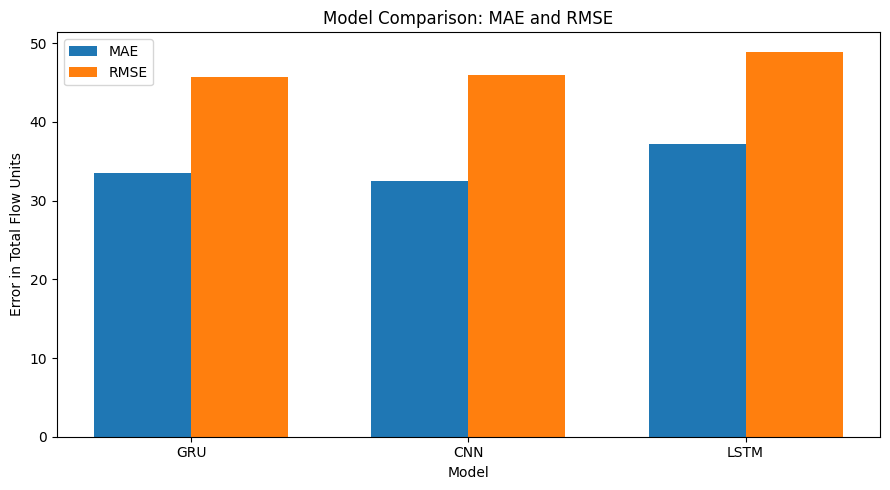

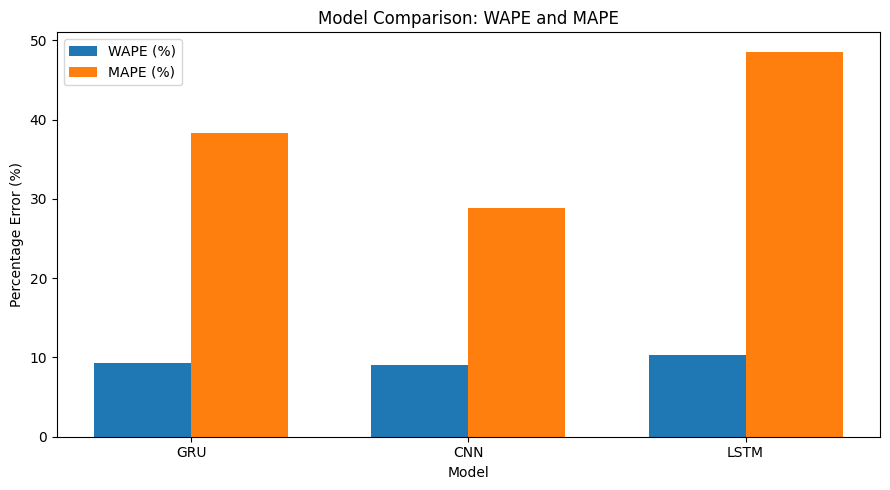

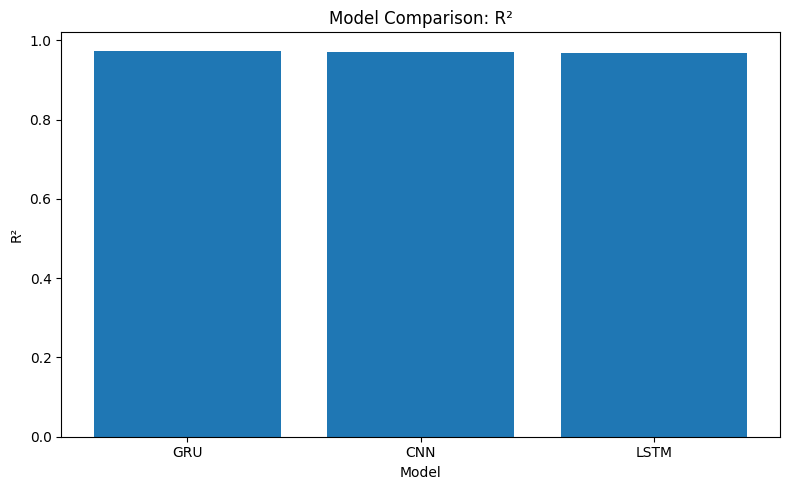

In [3]:
plt.figure(figsize=(9, 5))
x = np.arange(len(comparison_df))
width = 0.35
plt.bar(x - width / 2, comparison_df["MAE"], width, label="MAE")
plt.bar(x + width / 2, comparison_df["RMSE"], width, label="RMSE")
plt.xticks(x, comparison_df["Model"])
plt.title("Model Comparison: MAE and RMSE")
plt.xlabel("Model")
plt.ylabel("Error in Total Flow Units")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, comparison_df["WAPE_percent"], width, label="WAPE (%)")
plt.bar(x + width / 2, comparison_df["MAPE_percent"], width, label="MAPE (%)")
plt.xticks(x, comparison_df["Model"])
plt.title("Model Comparison: WAPE and MAPE")
plt.xlabel("Model")
plt.ylabel("Percentage Error (%)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["R2"])
plt.title("Model Comparison: R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()


## 4. Training and validation loss curves

These loss curves show whether each model converged during training and whether validation loss diverged from training loss. The y-axis is MSE on the normalised training scale.


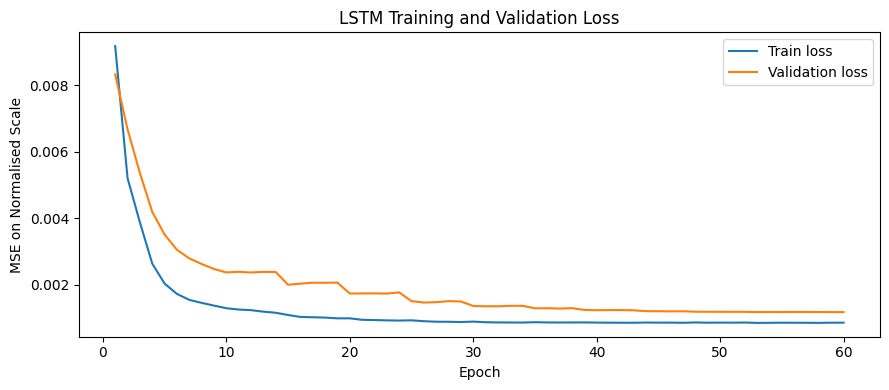

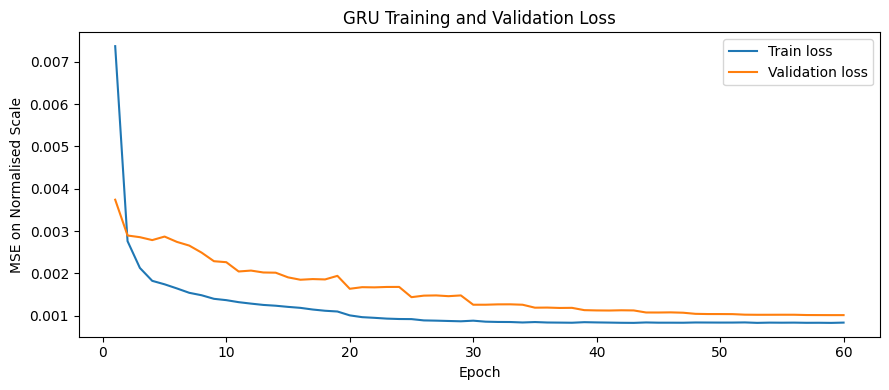

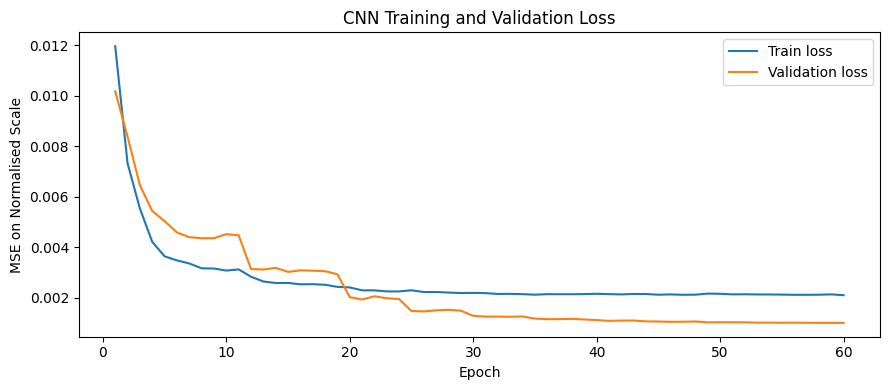

In [4]:
model_order = ["LSTM", "GRU", "CNN"]

for model_name in model_order:
    model_history = history_df[history_df["Model"] == model_name].sort_values("Epoch")
    if model_history.empty:
        continue

    plt.figure(figsize=(9, 4))
    plt.plot(model_history["Epoch"], model_history["loss"], label="Train loss")
    plt.plot(model_history["Epoch"], model_history["val_loss"], label="Validation loss")
    plt.title(f"{model_name} Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE on Normalised Scale")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 5. Actual vs predicted traffic flow for one complete test day

This plot is more meaningful than displaying the first 200 concatenated sequence rows, because it shows one continuous day at one SCATS node. The second available test day is used so that a complete day is available after the 12-interval input lookback.


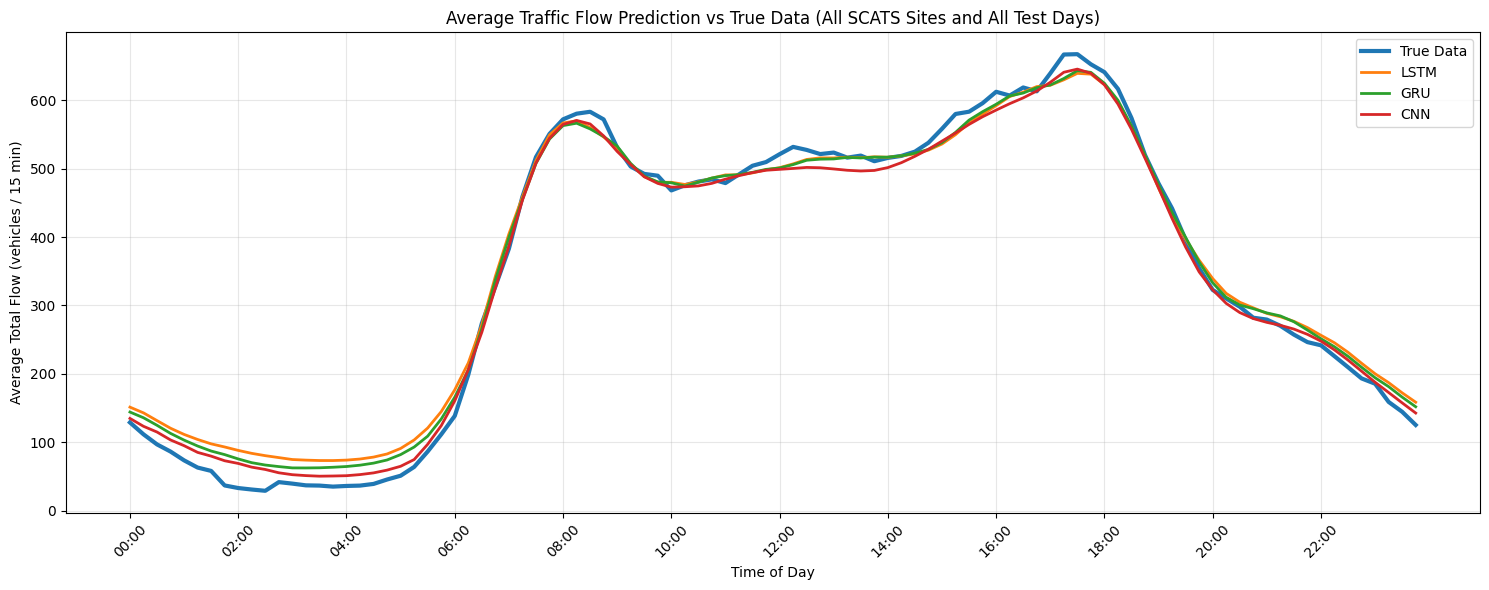

Number of SCATS sites included: 40
Number of test days included: 6
Test period: 2006-10-26 03:00:00 to 2006-10-31 23:45:00


In [8]:
# Average traffic-flow pattern across all SCATS sites and all test days
# This represents overall model behaviour on the complete test period,
# instead of selecting only one site and one day.

plot_df = predictions_df.copy()

# Create 15-minute time-of-day interval: 0 = 00:00, ..., 95 = 23:45
plot_df["interval"] = (
    plot_df["target_timestamp"].dt.hour * 4
    + plot_df["target_timestamp"].dt.minute // 15
)

# Create readable time labels
time_labels = [
    f"{hour:02d}:{minute:02d}"
    for hour in range(24)
    for minute in [0, 15, 30, 45]
]

# Actual flow is repeated once for each model in model_test_predictions.csv.
# Remove duplicated actual records before calculating the average actual flow.
actual_average = (
    plot_df[
        ["site_id", "target_timestamp", "interval", "actual_total_flow"]
    ]
    .drop_duplicates(["site_id", "target_timestamp"])
    .groupby("interval", as_index=False)["actual_total_flow"]
    .mean()
    .rename(columns={"actual_total_flow": "average_actual_flow"})
)

# Calculate average predicted flow for each model at each time interval
predicted_average = (
    plot_df
    .groupby(["Model", "interval"], as_index=False)["predicted_total_flow"]
    .mean()
)

plt.figure(figsize=(15, 6))

# Plot average actual traffic flow
plt.plot(
    actual_average["interval"],
    actual_average["average_actual_flow"],
    label="True Data",
    linewidth=3
)

# Plot average prediction from each model
for model_name in model_order:
    model_average = (
        predicted_average[
            predicted_average["Model"] == model_name
        ]
        .sort_values("interval")
    )

    if not model_average.empty:
        plt.plot(
            model_average["interval"],
            model_average["predicted_total_flow"],
            label=model_name,
            linewidth=2
        )

plt.title(
    "Average Traffic Flow Prediction vs True Data "
    "(All SCATS Sites and All Test Days)"
)
plt.xlabel("Time of Day")
plt.ylabel("Average Total Flow (vehicles / 15 min)")

# Show labels every 2 hours
tick_positions = list(range(0, 96, 8))
tick_labels = [time_labels[position] for position in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Number of SCATS sites included:", plot_df["site_id"].nunique())
print("Number of test days included:", plot_df["target_timestamp"].dt.date.nunique())
print(
    "Test period:",
    plot_df["target_timestamp"].min(),
    "to",
    plot_df["target_timestamp"].max()
)

## 6. Predicted vs actual scatter plot

A good model should place points close to the diagonal reference line. This plot uses all test predictions, rather than only one example day.


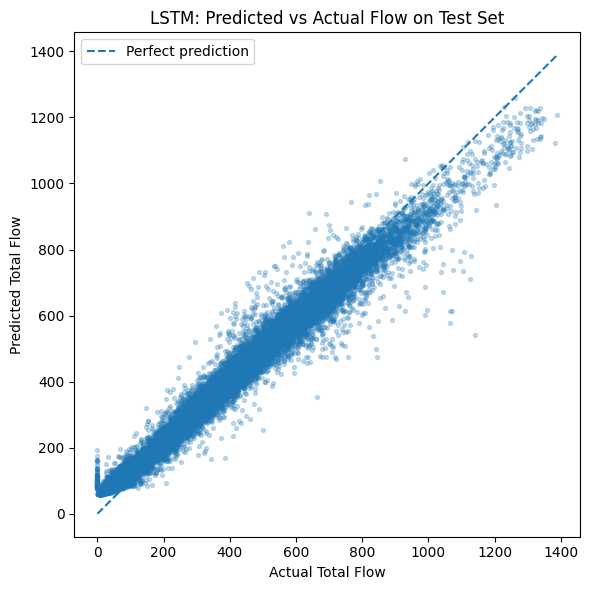

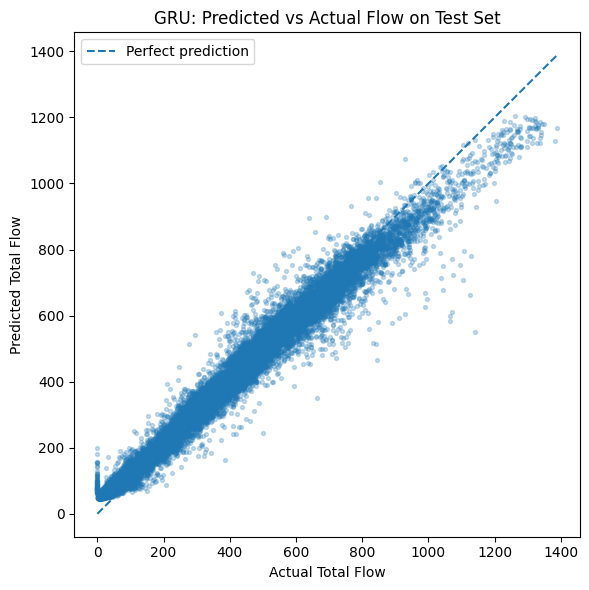

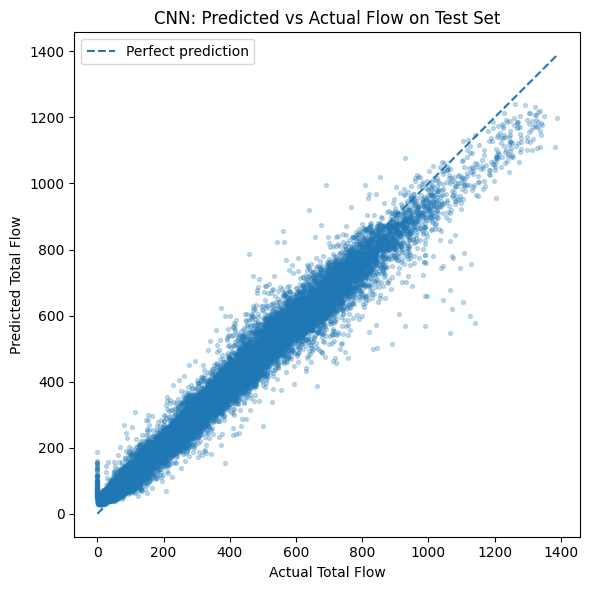

In [6]:
for model_name in model_order:
    model_predictions = predictions_df[predictions_df["Model"] == model_name]
    if model_predictions.empty:
        continue

    actual_values = model_predictions["actual_total_flow"]
    predicted_values = model_predictions["predicted_total_flow"]
    minimum = min(actual_values.min(), predicted_values.min())
    maximum = max(actual_values.max(), predicted_values.max())

    plt.figure(figsize=(6, 6))
    plt.scatter(actual_values, predicted_values, s=8, alpha=0.25)
    plt.plot([minimum, maximum], [minimum, maximum], linestyle="--", label="Perfect prediction")
    plt.title(f"{model_name}: Predicted vs Actual Flow on Test Set")
    plt.xlabel("Actual Total Flow")
    plt.ylabel("Predicted Total Flow")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 7. Absolute error distribution

The boxplot below shows how widely prediction errors are spread across the test set. A model with a lower median and fewer large errors is more reliable for later route-cost estimation.


/var/folders/pn/c_xh77l93q7g57d_3924ck5r0000gn/T/ipykernel_71672/2260138075.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(error_data, labels=model_order, showfliers=False)


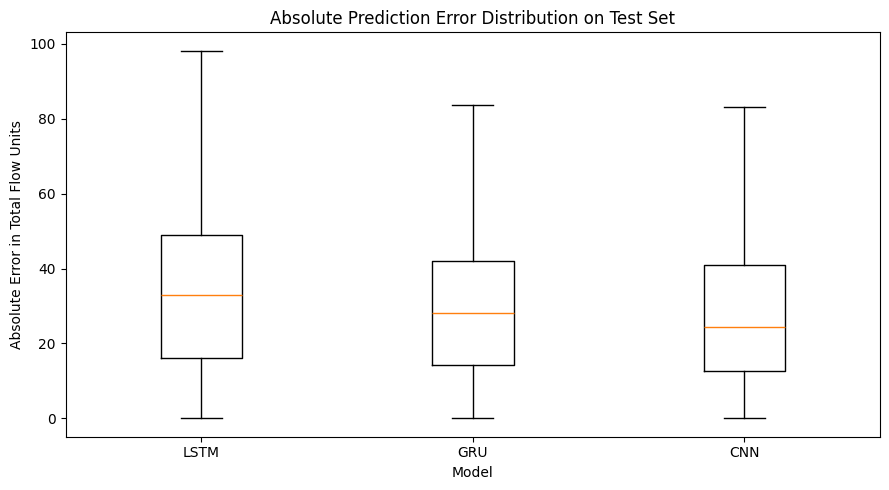

In [7]:

error_data = [
    predictions_df[predictions_df["Model"] == model_name]["absolute_error"].dropna()
    for model_name in model_order
]

plt.figure(figsize=(9, 5))
plt.boxplot(error_data, labels=model_order, showfliers=False)
plt.title("Absolute Prediction Error Distribution on Test Set")
plt.xlabel("Model")
plt.ylabel("Absolute Error in Total Flow Units")
plt.tight_layout()
plt.show()
